# Iris Flower Classification

## Importing Modules

In [239]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Reading CSV file

In [240]:
df = pd.read_csv("Iris.csv")

## Basic Information

In [241]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [242]:
df.shape

(150, 6)

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [244]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Checking Null Values

In [245]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [246]:
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## The "Id" property is not useful for us in prediction so we can drop it.

In [247]:
df.drop("Id",axis=1 , inplace=True)

In [248]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

## Finding out Relations

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

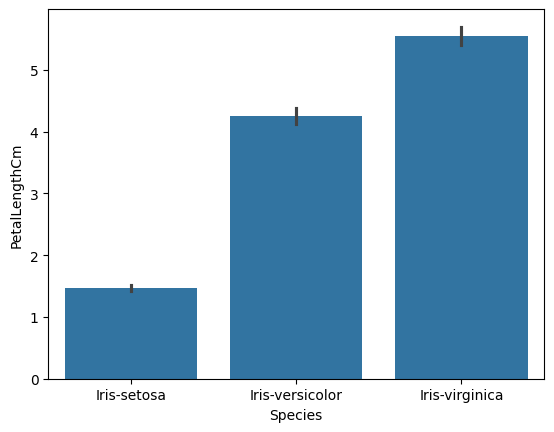

In [249]:
sns.barplot(x=df["Species"],y=df["PetalLengthCm"])

<Axes: xlabel='Species', ylabel='count'>

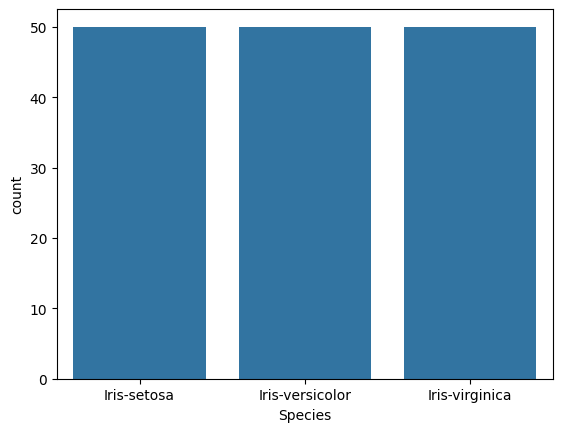

In [250]:
sns.countplot(x=df['Species'])

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

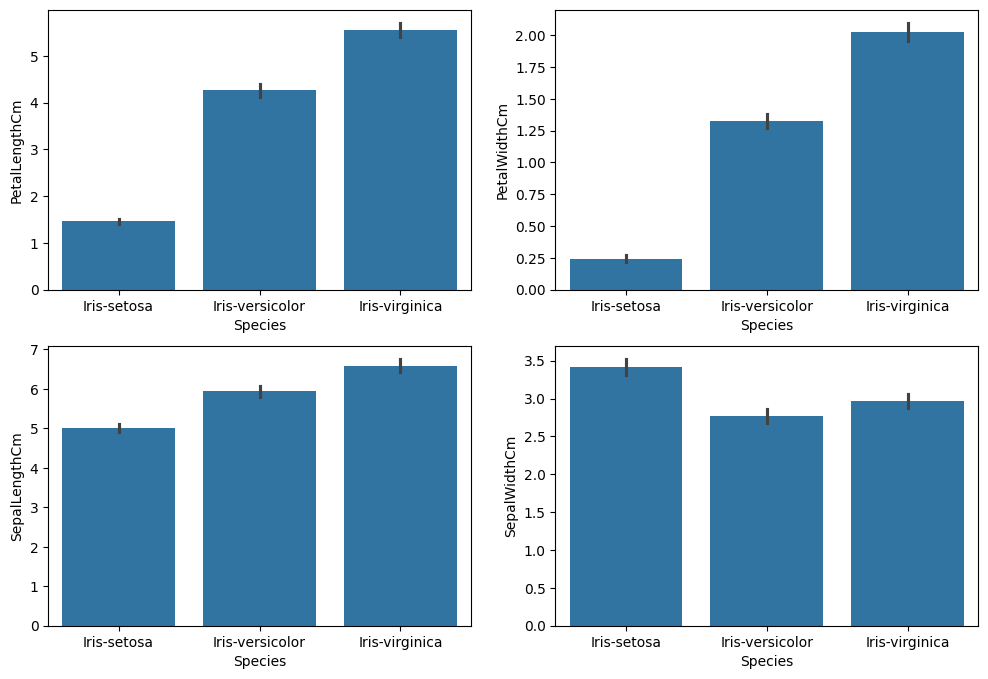

In [251]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.barplot(x=df["Species"],y=df["PetalLengthCm"])
plt.subplot(2,2,2)
sns.barplot(x=df["Species"],y=df["PetalWidthCm"])
plt.subplot(2,2,3)
sns.barplot(x=df["Species"],y=df["SepalLengthCm"])
plt.subplot(2,2,4)
sns.barplot(x=df["Species"],y=df["SepalWidthCm"])

## The correaltions between Features

<Axes: >

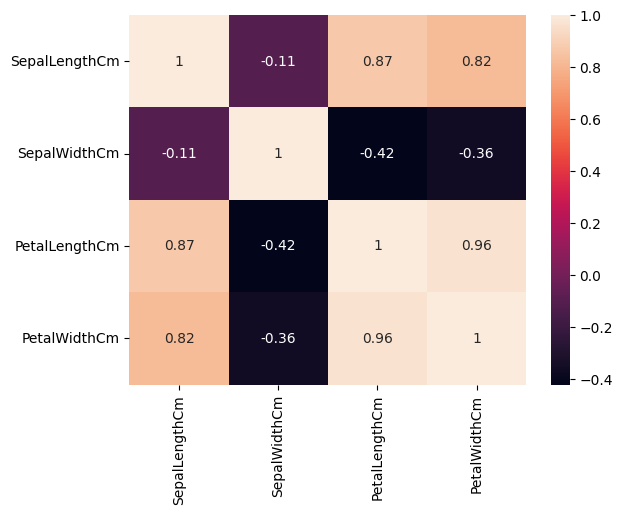

In [252]:
sns.heatmap(df.corr(numeric_only=True),annot=True )

## Separating the input and output variable

In [253]:
x = df.drop("Species",axis=1)
y = df['Species']

## Standard Scaling is also very important because it sets all the data in one scale

In [254]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

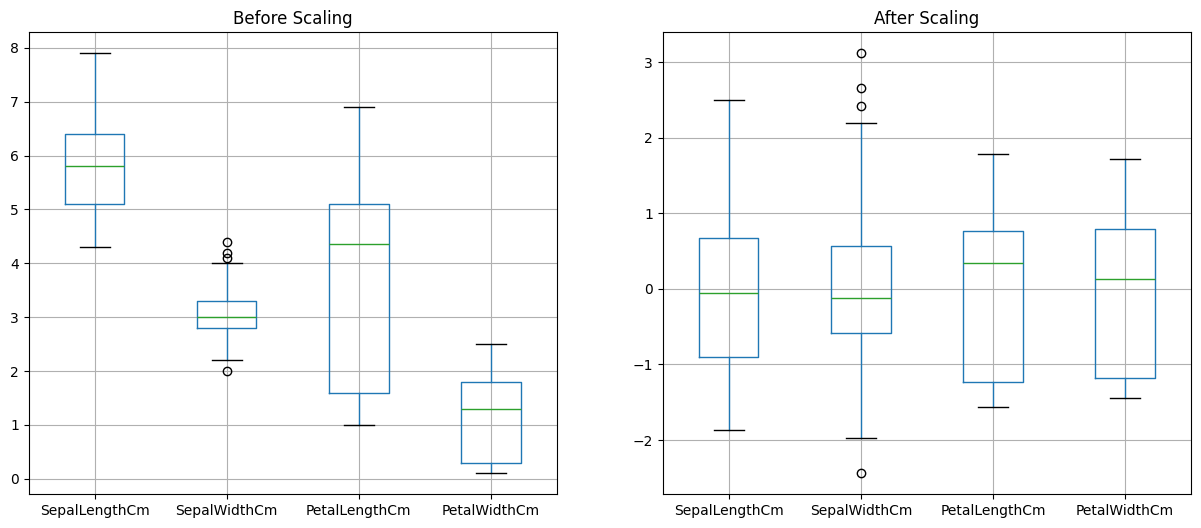

In [255]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled, columns=x.columns)

# Plot boxplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Before scaling
x.boxplot(ax=axes[0])
axes[0].set_title("Before Scaling")

# After scaling
X_scaled.boxplot(ax=axes[1])
axes[1].set_title("After Scaling")

plt.show()

## We can see the difference between data before scaling and after scaling

## Label Encoder

In [256]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
y = encode.fit_transform(y)

## Performing the Train-Test-Split

In [257]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

## Standardization of Data so that all the features lie on a same scale

In [258]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [259]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

## Decision Tree

In [260]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(max_depth=10)

In [261]:
model_dt.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [262]:
y_pred = model_dt.predict(X_test)

In [263]:
from sklearn.metrics import classification_report
print("Decision Tree")

print(classification_report(y_test , y_pred))

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## SVM

In [264]:
from sklearn.svm import SVC
model_svm = SVC(kernel="linear", probability=True, random_state=42)

model_svm.fit(X_train , y_train)
print("SVM")

y_pred = model_svm.predict(X_test)
print(classification_report(y_test , y_pred))

SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Random Forest Classifier

In [265]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()

model_rf.fit(X_train , y_train)
print("Random Forest")

y_pred = model_rf.predict(X_test)
print(classification_report(y_test , y_pred))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## Logistic Regression

In [266]:
from sklearn.linear_model import LogisticRegression
model_log = LogisticRegression()

model_log.fit(X_train , y_train)
print("Logistic Regression")
y_pred = model_log.predict(X_test)
print(classification_report(y_test , y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## The SVM is giving the best prediction with high accuracy

In [267]:
import joblib
joblib.dump(model_svm , "iris_model.pkl")
joblib.dump(scaler , "iris_scaler.pkl")
joblib.dump(encode , "iris_label_encoder.pkl")

['iris_label_encoder.pkl']